In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import dblquad

# ==========================================
# 1. CONSTANTES FÍSICAS
# ==========================================
G_F = 1.166e-11           # Constante de Fermi [MeV^-2]
sin2_theta_w = 0.23868     # Ángulo de mezcla de Weinberg
M_Xe = 131.0 * 931.5      # Masa del núcleo Xe-131 [MeV]
Z = 54.0                  # Protones del Xenón
N = 131.0 - 54.0          # Neutrones del Xenón
Q_w = N - Z * (1 - 4 * sin2_theta_w)  # Carga débil

hbar_c2 = 3.894e-22       # Factor de conversión a [cm^2]

# --- Constantes para el decaimiento Teórico del Boro-8 ---
m_e_MeV = 0.510998        # Masa del electrón en MeV
Q_B8_MeV = 17.98         # Q-value aproximado para el Boro-8 [MeV]



# 1. Cargamos el archivo saltando las 15 primeras líneas de texto explicativo
datos_B8 = np.loadtxt('b8spectrum.txt', skiprows=15)
datos_acceptance_XENONnT = np.loadtxt('XENONnT_acceptance.csv', skiprows=0, delimiter=',')
datos_acceptance_Panda = np.loadtxt('AcceptancePanda.csv', skiprows=0, delimiter=',')
datos_acceptance_LZ = np.loadtxt('AcceptanceLZ.csv', skiprows=0, delimiter=',')

# 2. Extraemos las dos primeras columnas según indica el archivo original
energias_MeV = datos_B8[:, 0]  # Primera columna: Energía del neutrino 
espectro_norm = datos_B8[:, 1] # Segunda columna: Espectro "best-estimated"


energias_recoil_keV_desordenadas = datos_acceptance_XENONnT[:, 0]
aceptancia_y_desordenada = datos_acceptance_XENONnT[:, 1]

energias_recoil_keV_Panda_desordenadas = datos_acceptance_Panda[:, 0]
aceptancia_y_Panda_desordenada = datos_acceptance_Panda[:, 1]

energias_recoil_keV_desordenadas = datos_acceptance_XENONnT[:, 0]
aceptancia_y_desordenada = datos_acceptance_XENONnT[:, 1]

energias_recoil_keV_LZ_desordenadas = datos_acceptance_LZ[:, 0]
aceptancia_y_LZ_desordenada = datos_acceptance_LZ[:, 1]

indices_ordenados = np.argsort(energias_recoil_keV_desordenadas)
energias_recoil_keV = energias_recoil_keV_desordenadas[indices_ordenados]
aceptancia_y = aceptancia_y_desordenada[indices_ordenados]

indices_ordenados_Panda = np.argsort(energias_recoil_keV_Panda_desordenadas)
energias_recoil_keV_Panda = energias_recoil_keV_Panda_desordenadas[indices_ordenados_Panda]
aceptancia_y_Panda = aceptancia_y_Panda_desordenada[indices_ordenados_Panda]

indices_ordenados_LZ = np.argsort(energias_recoil_keV_LZ_desordenadas)
energias_recoil_keV_LZ = energias_recoil_keV_LZ_desordenadas[indices_ordenados_LZ]
aceptancia_y_LZ = aceptancia_y_LZ_desordenada[indices_ordenados_LZ]

ultimo_valor_aceptancia = aceptancia_y[-1]
ultimo_valor_aceptancia_Panda = aceptancia_y_Panda[-1]
ultimo_valor_aceptancia_LZ = aceptancia_y_LZ[-1]

# 3. Creamos el motor de interpolación matemática
# 'linear' une los puntos con líneas rectas. Si pide una energía que no 
# está en la tabla (ej. 20 MeV), fill_value=0.0 asegura que devuelva cero.
flujo_B8_interpolado = interp1d(
    energias_MeV, 
    espectro_norm, 
    kind='linear', 
    bounds_error=False, 
    fill_value=0.0
)

# 3. Creamos el motor de interpolación matemática
# 'linear' une los puntos con líneas rectas. Si la integral pide una energía que no 
# está en la gráfica del detector, fill_value=0.0 asegura que la aceptancia sea cero.
aceptancia_XENONnT_interpolada = interp1d(
    energias_recoil_keV, 
    aceptancia_y, 
    kind='linear', 
    bounds_error=False, 
    fill_value=(0.0,ultimo_valor_aceptancia)
)

aceptancia_PandaX_interpolada = interp1d(
    energias_recoil_keV_Panda, 
    aceptancia_y_Panda, 
    kind='linear', 
    bounds_error=False, 
    fill_value=(0.0,ultimo_valor_aceptancia_Panda)
)

aceptancia_LZ_interpolada = interp1d(
    energias_recoil_keV_LZ, 
    aceptancia_y_LZ, 
    kind='linear', 
    bounds_error=False, 
    fill_value=(0.0,ultimo_valor_aceptancia_LZ)
)
# ==========================================
# 2. FUNCIONES FÍSICAS
# ==========================================

def flujo_B8_real(E_nu):
    if E_nu < 0.1 or E_nu > 16.5: # Límite máximo ampliado al final de la tabla
        return 0.0
        
    flujo_total_SSM = 5.25e6 
    
    return flujo_B8_interpolado(E_nu)*flujo_total_SSM

# --- B. EL FLUJO TEÓRICO (ESPACIO DE FASES) ---
def espectro_fase_fermi_bruto(E_nu):
    """ Núcleo matemático de la cinemática pura """
    E_e = Q_B8_MeV - E_nu
    if E_e <= m_e_MeV: return 0.0
    return (E_nu**2) * E_e * np.sqrt(E_e**2 - m_e_MeV**2)

def dsigma_dT(E_nu, T_keV):
    """
    Sección eficaz diferencial clásica CEvNS
    Salida en [cm^2 / keV]
    """
    T_MeV = T_keV * 1e-3 
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    
    if E_nu < E_min:
        return 0.0

    F_T = 1.0 # Factor de forma (Asumido 1 para este ejemplo base)
    
    # Término cinemático clásico
    termino_cinematico = 1.0 - (M_Xe * T_MeV) / (2.0 * E_nu**2)
    
    if termino_cinematico < 0:
        return 0.0

    sigma_0 = (G_F**2 * M_Xe) / (4.0 * np.pi) * (Q_w**2)
    dSig_dT_MeV = sigma_0 * termino_cinematico * F_T**2 * hbar_c2
    
    return dSig_dT_MeV * 1e-3 

def chi_cuadrado_1variable(obs, exp, sigma):
    # Aseguramos que todo sean arrays de NumPy para cálculo vectorial
    O = np.array(obs, dtype=float)
    E = np.array(exp, dtype=float)
    S = np.array(sigma, dtype=float)
    
    # Protegemos contra divisiones por cero (si un bin tiene error 0, su chi2 es 0)
    varianza = S**2
    varianza_segura = np.where(varianza == 0, np.inf, varianza)
    
    # Ecuación universal del Chi-cuadrado
    chi2_componentes = ((O - E)**2) / varianza_segura
    chi2_total = np.sum(chi2_componentes)
    
    return chi2_total, chi2_componentes

def eficiencia_XENONnT(T_keV):
   # El corte estricto del análisis (0.5 keV)
    if T_keV < 0.5:
        return 0.0
        
    # Parámetros ajustados a la curva negra "Combined Acceptance"
    E_max = 0.127  # Techo asintótico (~12.7%)
    k = 2.5        # Pendiente de crecimiento estadístico
    T_0 = 1.9      # Punto de inflexión en keV
    
    # Ecuación logística sigmoide
    eficiencia = E_max / (1.0 + np.exp(-k * (T_keV - T_0)))
    
    # Nos aseguramos de que no haya un "salto" artificial justo en 0.5 keV
    # restando el valor base en ese punto para que nazca suavemente de cero.
    offset = E_max / (1.0 + np.exp(-k * (0.5 - T_0)))
    
    return eficiencia - offset
    

def eficiencia_XENONnT_interpolada(T_keV):

    return float(aceptancia_XENONnT_interpolada(T_keV))
    

def eficiencia_PandaX(T_keV):
    # El paper establece un umbral duro de análisis en ~1.1 keV
   # Mantenemos tu exigencia estricta: cero absoluto por debajo de 1.1 keV
    if T_keV < 1.1:
        return 0.0
        
    # Parámetros ajustados a la curva negra continua (escala logarítmica)
    E_max = 0.095  # Techo asintótico. Al restar el offset quedará en ~8.5%
    k = 4.5        # Pendiente de subida muy pronunciada
    T_0 = 1.6      # Punto de inflexión (donde alcanza la mitad de su eficiencia)
    
    # Ecuación logística sigmoide
    eficiencia = E_max / (1.0 + np.exp(-k * (T_keV - T_0)))
    
    # Restamos el valor en 1.1 keV para que nazca de forma continua
    offset = E_max / (1.0 + np.exp(-k * (1.1 - T_0)))
    
    return eficiencia - offset

def eficiencia_PandaX_interpolada(T_keV):
    # Usamos el motor de interpolación que creaste a partir de AcceptancePanda.csv
    return float(aceptancia_PandaX_interpolada(T_keV))

def eficiencia_LZ_interpolada(T_keV):
    # Usamos el motor de interpolación que creaste a partir de AcceptanceLZ.csv
    return float(aceptancia_LZ_interpolada(T_keV))

# ==========================================
# 3. INTEGRACIÓN CLÁSICA
# ==========================================

def dNdT_integrando_realista_XENONnT(E_nu, T_keV):
    """
    El integrando ahora es: Flujo * Sección Eficaz * Eficiencia
    """
    flujo = flujo_B8_real(E_nu)
    seccion = dsigma_dT(E_nu, T_keV)
    eficiencia = eficiencia_XENONnT(T_keV)
    
    return flujo * seccion * eficiencia
    return flujo * seccion


def dNdT_integrando_realista_XENONnT_interpol(E_nu, T_keV):
    """
    El integrando ahora es: Flujo * Sección Eficaz * Eficiencia
    """
    flujo = flujo_B8_real(E_nu)
    seccion = dsigma_dT(E_nu, T_keV)
    eficiencia = eficiencia_XENONnT_interpolada(T_keV)
    
    return flujo * seccion * eficiencia
    return flujo * seccion

def dNdT_integrando_realista_XENONnT_interpol_prueba(E_nu, T_keV):
    """
    El integrando ahora es: Flujo * Sección Eficaz * Eficiencia
    """
    flujo = flujo_B8_real(E_nu)
    seccion = dsigma_dT(E_nu, T_keV)
    eficiencia = eficiencia_XENONnT_interpolada(T_keV)
    
    return flujo  * eficiencia

def dNdT_integrando_realista_PandaX(E_nu, T_keV):
    """
    El integrando ahora es: Flujo * Sección Eficaz * Eficiencia
    """
    flujo = flujo_B8_real(E_nu)
    seccion = dsigma_dT(E_nu, T_keV)
    eficiencia = eficiencia_PandaX(T_keV)
    
    return flujo * seccion * eficiencia
    return flujo * seccion

def dNdT_integrando_realista_PandaX_interpol(E_nu, T_keV):
    """
    El integrando ahora es: Flujo * Sección Eficaz * Eficiencia (Interpolada)
    """
    flujo = flujo_B8_real(E_nu)
    seccion = dsigma_dT(E_nu, T_keV)
    eficiencia = eficiencia_PandaX_interpolada(T_keV)
    return flujo * seccion * eficiencia

def dNdT_integrando_realista_LZ_interpol(E_nu, T_keV):
    """
    El integrando ahora es: Flujo * Sección Eficaz * Eficiencia (Interpolada)
    """
    flujo = flujo_B8_real(E_nu)
    seccion = dsigma_dT(E_nu, T_keV)
    eficiencia = eficiencia_LZ_interpolada(T_keV)
    return flujo * seccion * eficiencia

def calcular_dNdT_XENONnT(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.332026977057975 
    if E_min >= E_max: return 0.0
    
    # Usamos el nuevo integrando
    integral, err = quad(dNdT_integrando_realista_XENONnT, E_min, E_max, args=(T_keV,))
    return integral * 86400

def calcular_dNdT_XENONnT_interpol(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.332026977057975
    if E_min >= E_max: return 0.0
    
    # Usamos el nuevo integrando
    integral, err = quad(dNdT_integrando_realista_XENONnT_interpol, E_min, E_max, args=(T_keV,))
    return integral * 86400

def calcular_dNdT_XENONnT_interpol_prueba(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.332026977057975 
    if E_min >= E_max: return 0.0
    
    # Usamos el nuevo integrando
    integral, err = quad(dNdT_integrando_realista_XENONnT_interpol_prueba, E_min, E_max, args=(T_keV,))
    return integral * 86400

def calcular_dNdT_PandaX(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.332026977057975 
    if E_min >= E_max: return 0.0
    
    # Usamos el nuevo integrando
    integral, err = quad(dNdT_integrando_realista_PandaX, E_min, E_max, args=(T_keV,))
    return integral * 86400

def calcular_dNdT_PandaX_interpol(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.332026977057975
    if E_min >= E_max: return 0.0
    
    # Usamos el nuevo integrando interpolado
    integral, err = quad(dNdT_integrando_realista_PandaX_interpol, E_min, E_max, args=(T_keV,))
    return integral * 86400

def calcular_dNdT_LZ_interpol(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.332026977057975 
    if E_min >= E_max: return 0.0
    
    # Usamos el nuevo integrando interpolado
    integral, err = quad(dNdT_integrando_realista_LZ_interpol, E_min, E_max, args=(T_keV,))
    return integral * 86400


def tasa_total_ton_dia_XENONnT(T_min_keV, T_max_keV):
    """
    Integra el espectro diferencial dN/dT entre el umbral inferior y superior.
    Devuelve la tasa total en [Eventos / tonelada / día]
    """
    # Integramos la función calcular_dNdT sobre la variable de retroceso T
    # epsrel y epsabs se ajustan un poco para que la doble integral no tarde demasiado
    resultado_atomo, error = quad(calcular_dNdT_XENONnT, T_min_keV, T_max_keV, epsrel=1e-3)
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    #print(atomos_por_tonelada*3.5)
    
    # Convertimos a toneladas (usando la variable que definiste en el bloque 4)
    tasa_tonelada = resultado_atomo * atomos_por_tonelada
    return tasa_tonelada

def tasa_total_ton_dia_XENONnT_interpol(T_min_keV, T_max_keV):
    """
    Integra el espectro diferencial dN/dT entre el umbral inferior y superior.
    Devuelve la tasa total en [Eventos / tonelada / día]
    """
    # Integramos la función calcular_dNdT sobre la variable de retroceso T
    # epsrel y epsabs se ajustan un poco para que la doble integral no tarde demasiado
    resultado_atomo, error = quad(calcular_dNdT_XENONnT_interpol, T_min_keV, T_max_keV, epsrel=1e-3)
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    #print(atomos_por_tonelada*3.5)
    
    # Convertimos a toneladas (usando la variable que definiste en el bloque 4)
    tasa_tonelada = resultado_atomo * atomos_por_tonelada
    return tasa_tonelada

def tasa_total_ton_dia_XENONnT_interpol_prueba(T_min_keV, T_max_keV):
    """
    Integra el espectro diferencial dN/dT entre el umbral inferior y superior.
    Devuelve la tasa total en [Eventos / tonelada / día]
    """
    # Integramos la función calcular_dNdT sobre la variable de retroceso T
    # epsrel y epsabs se ajustan un poco para que la doble integral no tarde demasiado
    resultado_atomo, error = quad(calcular_dNdT_XENONnT_interpol_prueba, T_min_keV, T_max_keV, epsrel=1e-3)
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    #print(atomos_por_tonelada*3.5)
    
    # Convertimos a toneladas (usando la variable que definiste en el bloque 4)
    tasa_tonelada = resultado_atomo * atomos_por_tonelada
    return tasa_tonelada

def tasa_total_ton_dia_PandaX(T_min_keV, T_max_keV):
    """
    Integra el espectro diferencial dN/dT entre el umbral inferior y superior.
    Devuelve la tasa total en [Eventos / tonelada / día]
    """
    # Integramos la función calcular_dNdT sobre la variable de retroceso T
    # epsrel y epsabs se ajustan un poco para que la doble integral no tarde demasiado
    resultado_atomo, error = quad(calcular_dNdT_PandaX, T_min_keV, T_max_keV, epsrel=1e-3)
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    
    # Convertimos a toneladas (usando la variable que definiste en el bloque 4)
    tasa_tonelada = resultado_atomo * atomos_por_tonelada
    return tasa_tonelada

def tasa_total_ton_dia_PandaX_interpol(T_min_keV, T_max_keV):
    """
    Integra el espectro diferencial dN/dT entre el umbral inferior y superior.
    Devuelve la tasa total en [Eventos / tonelada / día]
    """
    # Integramos la nueva función calcular_dNdT_PandaX_interpol
    resultado_atomo, error = quad(calcular_dNdT_PandaX_interpol, T_min_keV, T_max_keV, epsrel=1e-3)
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    
    # Convertimos a toneladas
    tasa_tonelada = resultado_atomo * atomos_por_tonelada
    return tasa_tonelada

def tasa_total_ton_dia_LZ_interpol(T_min_keV, T_max_keV):
    """
    Integra el espectro diferencial dN/dT entre el umbral inferior y superior.
    Devuelve la tasa total en [Eventos / tonelada / día]
    """
    # Integramos la nueva función calcular_dNdT_LZ_interpol
    resultado_atomo, error = quad(calcular_dNdT_LZ_interpol, T_min_keV, T_max_keV, epsrel=1e-3)
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    
    # Convertimos a toneladas
    tasa_tonelada = resultado_atomo * atomos_por_tonelada
    return tasa_tonelada


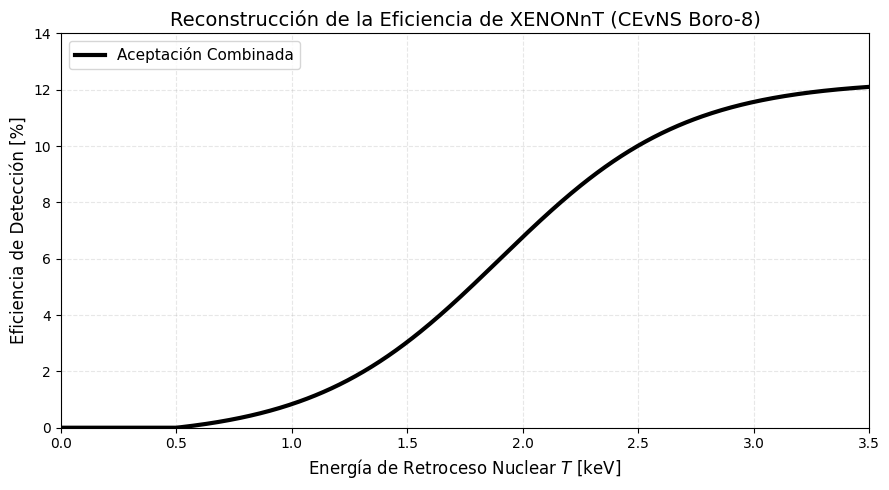

In [2]:
# Vectorizamos para plotear
eficiencia_vec = np.vectorize(eficiencia_XENONnT)

# Eje X de 0 a 3.5 keV
T_vals = np.linspace(0.0, 3.5, 500)
eff_vals = eficiencia_vec(T_vals) * 100 

# Ploteamos
plt.figure(figsize=(9, 5))
plt.plot(T_vals, eff_vals, color='black', linewidth=3, 
         label='Aceptación Combinada')

plt.title('Reconstrucción de la Eficiencia de XENONnT (CEvNS Boro-8)', fontsize=14)
plt.xlabel('Energía de Retroceso Nuclear $T$ [keV]', fontsize=12)
plt.ylabel('Eficiencia de Detección [%]', fontsize=12)

plt.xlim(0, 3.5)
plt.ylim(0, 14) 
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

El último valor distinto de cero está en el índice: 480
19.78876600265601


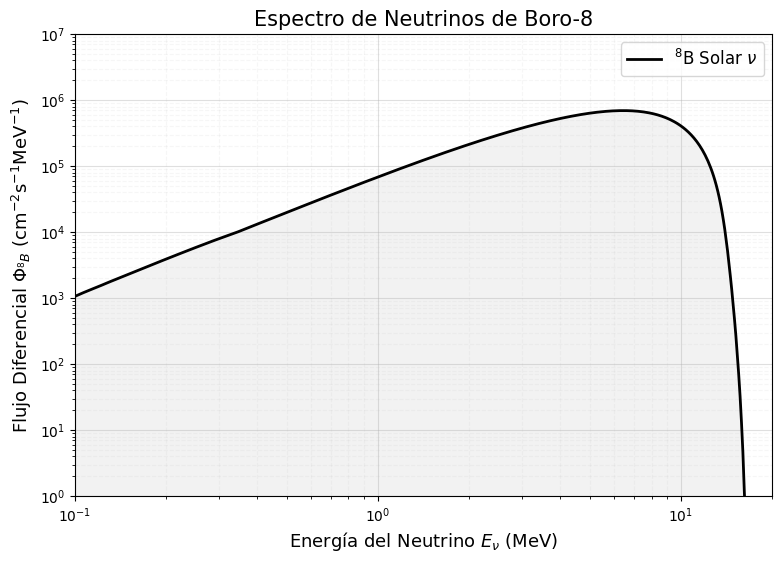

In [3]:
# ==========================================
# GRÁFICA DE VALIDACIÓN DEL FLUJO SOLAR 
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Generamos 500 puntos espaciados logarítmicamente entre 0.1 y 16.5
energias_plot_MeV = np.logspace(np.log10(0.1), np.log10(20), 500)

# Evaluamos tu función de flujo tabulado
flujos_evaluados1 = [flujo_B8_real(E) for E in energias_plot_MeV]

plt.figure(figsize=(9,6))

# Usamos la "r" delante de la string para que el \nu de LaTeX funcione perfecto
plt.plot(energias_plot_MeV, flujos_evaluados1, 'k-', lw=2.0, label=r'$^{8}$B Solar $\nu$')

plt.fill_between(energias_plot_MeV, flujos_evaluados1, color='gray', alpha=0.1)

# AMBOS EJES EN LOGARÍTMICO
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'Energía del Neutrino $E_{\nu}$ (MeV)', fontsize=13)
plt.ylabel(r'Flujo Diferencial $\Phi_{^{8}B}$ (cm$^{-2}$s$^{-1}$MeV$^{-1}$)', fontsize=13)
plt.title('Espectro de Neutrinos de Boro-8', fontsize=15)

# Ajustamos los límites exactamente como en el paper
plt.xlim(0.1, 20)
plt.ylim(1e0, 1e7) # Dejamos aire por arriba para la leyenda

plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.1)
plt.legend(fontsize=12, loc='upper right')


indices_no_cero = np.nonzero(flujos_evaluados1)[0]

if len(indices_no_cero) > 0:
    # Tomamos el último elemento del array de índices
    ultima_posicion = indices_no_cero[-1] 
    print(f"El último valor distinto de cero está en el índice: {ultima_posicion}")
else:
    print("Todos los valores son cero.")

print(energias_plot_MeV[498])

plt.show()

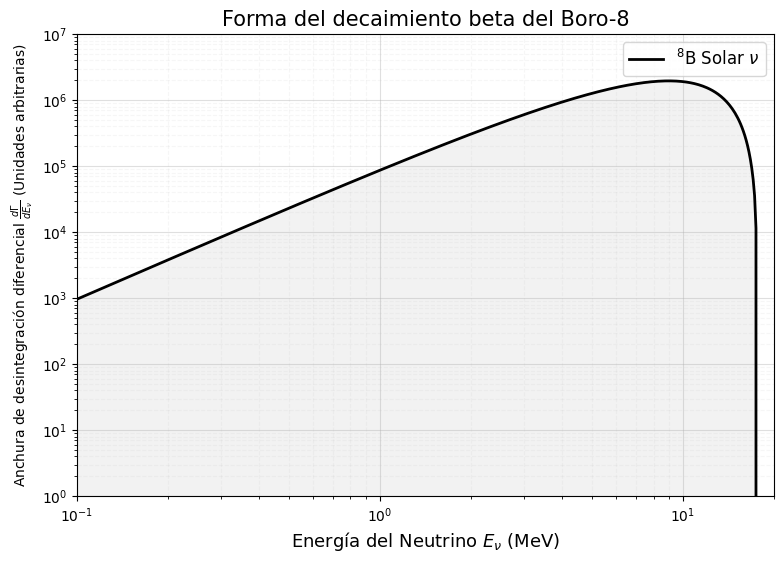

In [4]:
# ==========================================
# GRÁFICA DE VALIDACIÓN DEL FLUJO SOLAR POR DECAIMIENTO BETA (ESPACIO DE FASES)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Generamos 500 puntos espaciados logarítmicamente entre 0.1 y 18


# Evaluamos tu función de flujo tabulado
flujos_evaluados = [espectro_fase_fermi_bruto(E)*300 for E in energias_plot_MeV]

plt.figure(figsize=(9,6))

# Usamos la "r" delante de la string para que el \nu de LaTeX funcione perfecto
plt.plot(energias_plot_MeV, flujos_evaluados, 'k-', lw=2.0, label=r'$^{8}$B Solar $\nu$')

plt.fill_between(energias_plot_MeV, flujos_evaluados, color='gray', alpha=0.1)

# AMBOS EJES EN LOGARÍTMICO
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'Energía del Neutrino $E_{\nu}$ (MeV)', fontsize=13)
plt.ylabel(r'Anchura de desintegración diferencial $\frac{d\Gamma}{dE_\nu}$ (Unidades arbitrarias)', fontsize=10)
plt.title('Forma del decaimiento beta del Boro-8', fontsize=15)

# Ajustamos los límites exactamente como en el paper
plt.xlim(0.1, 20)
plt.ylim(1e0, 1e7) # Dejamos aire por arriba para la leyenda

plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.1)
plt.legend(fontsize=12, loc='upper right')

plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_3728\2782987015.py:11: RuntimeWarning: invalid value encountered in divide
  cociente_shape = flujo_norm_interpolado / flujo_norm_beta


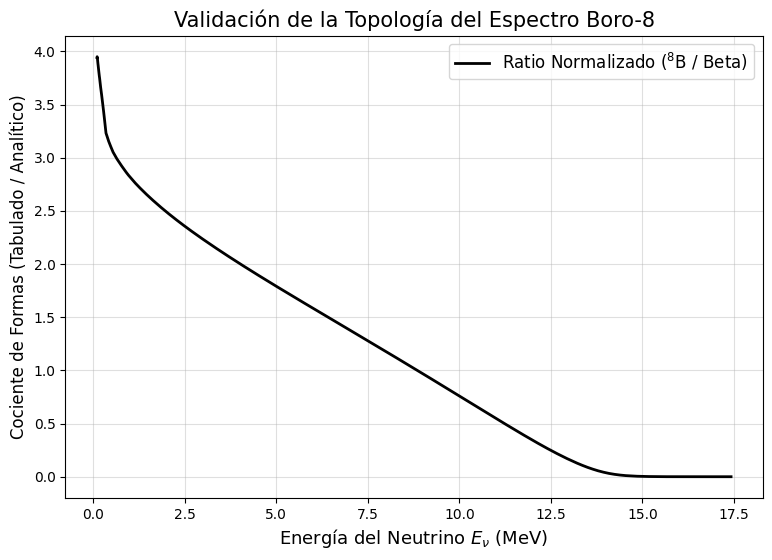

In [5]:
# ==========================================
# GRÁFICA DE VALIDACIÓN RIGUROSA DE FORMA (SHAPE)
# ==========================================
area_tabulada = np.trapezoid(flujos_evaluados, energias_plot_MeV)

flujo_norm_interpolado = np.array(flujos_evaluados1)/5.25e6
flujo_norm_beta = np.array(flujos_evaluados)/area_tabulada

# 2. COCIENTE DE LAS FORMAS NORMALIZADAS
# Si la forma es idéntica, esto oscilará exactamente alrededor de 1.0
cociente_shape = flujo_norm_interpolado / flujo_norm_beta

plt.figure(figsize=(9,6))

# Usamos la "r" delante de la string para que el \nu de LaTeX funcione perfecto
plt.plot(energias_plot_MeV, cociente_shape, 'k-', lw=2.0, label=r'Ratio Normalizado ($^{8}$B / Beta)')


# EL EJE X SIGUE SIENDO LOG (Porque la energía abarca varios órdenes)
plt.xscale('linear')

# EL EJE Y DEBE SER LINEAL PARA VER RESIDUOS
plt.yscale('linear') 

plt.xlabel(r'Energía del Neutrino $E_{\nu}$ (MeV)', fontsize=13)
plt.ylabel(r'Cociente de Formas (Tabulado / Analítico)', fontsize=12)
plt.title('Validación de la Topología del Espectro Boro-8', fontsize=15)


plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.1)
plt.legend(fontsize=12, loc='upper right')

plt.show()

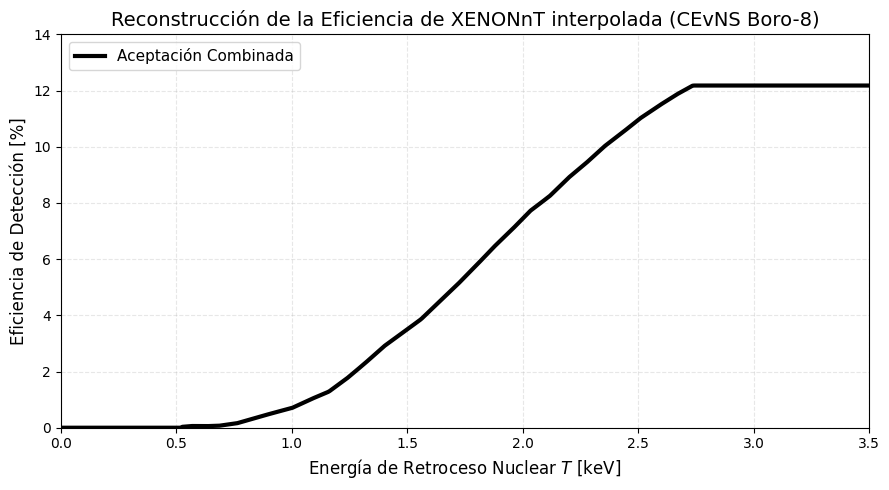

In [6]:
#Grafica eficiencia XENONnT con la función de interpolación creada a partir de los datos tabulados

# Vectorizamos para plotear
eficiencia_vec = np.vectorize(eficiencia_XENONnT_interpolada)

# Eje X de 0 a 3.5 keV
T_vals = np.linspace(0.0, 3.5, 500)
eff_vals = eficiencia_vec(T_vals) * 100 

# Ploteamos
plt.figure(figsize=(9, 5))
plt.plot(T_vals, eff_vals, color='black', linewidth=3, 
         label='Aceptación Combinada')

plt.title('Reconstrucción de la Eficiencia de XENONnT interpolada (CEvNS Boro-8)', fontsize=14)
plt.xlabel('Energía de Retroceso Nuclear $T$ [keV]', fontsize=12)
plt.ylabel('Eficiencia de Detección [%]', fontsize=12)

plt.xlim(0, 3.5)
plt.ylim(0, 14) 
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

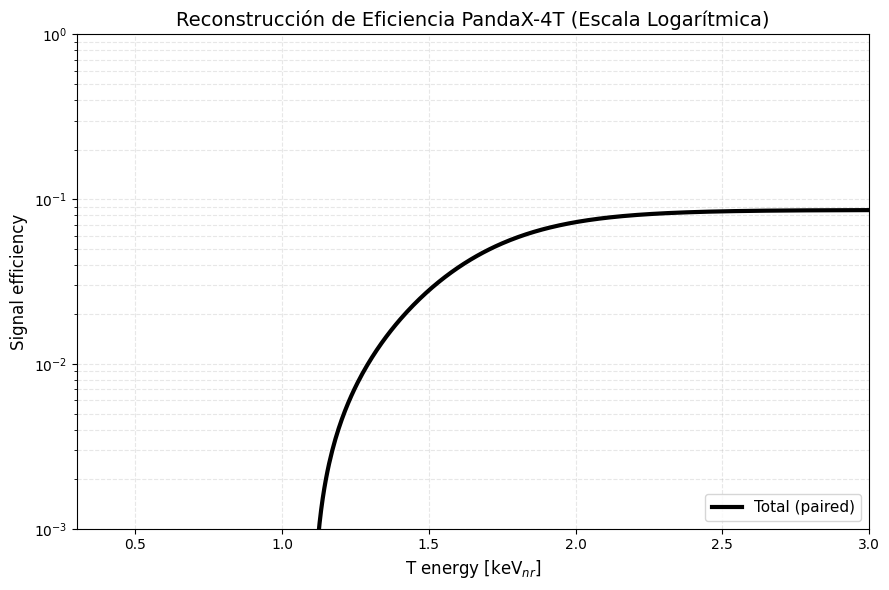

In [7]:
#Grafica eficiencia PandaX

# Vectorizamos para plotear
eficiencia_vec_P = np.vectorize(eficiencia_PandaX)

# Eje X de 0.3 a 3.0 keV (Igual que en el paper)
T_vals = np.linspace(0.3, 3.0, 500)
# ¡Ojo! No multiplicamos por 100 aquí para mantener la escala absoluta de 10^-3 a 10^0
eff_vals_P = eficiencia_vec_P(T_vals) 

# Reemplazamos los ceros por un número minúsculo para que el logaritmo no dé error
eff_vals_P = np.where(eff_vals_P == 0, 1e-10, eff_vals_P)

# ==========================================
# CREACIÓN DE LA GRÁFICA (ESTILO PAPER)
# ==========================================
plt.figure(figsize=(9, 6))

plt.plot(T_vals, eff_vals_P, color='black', linewidth=3, 
         label='Total (paired)')


# Configuramos el eje Y en escala logarítmica para igualar tu imagen
plt.yscale('log')
plt.ylim(1e-3, 1e0) # De 10^-3 a 10^0
plt.xlim(0.3, 3.0)

# Estética
plt.title('Reconstrucción de Eficiencia PandaX-4T (Escala Logarítmica)', fontsize=14)
plt.xlabel('T energy [keV$_{nr}$]', fontsize=12)
plt.ylabel('Signal efficiency', fontsize=12)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

plt.show()

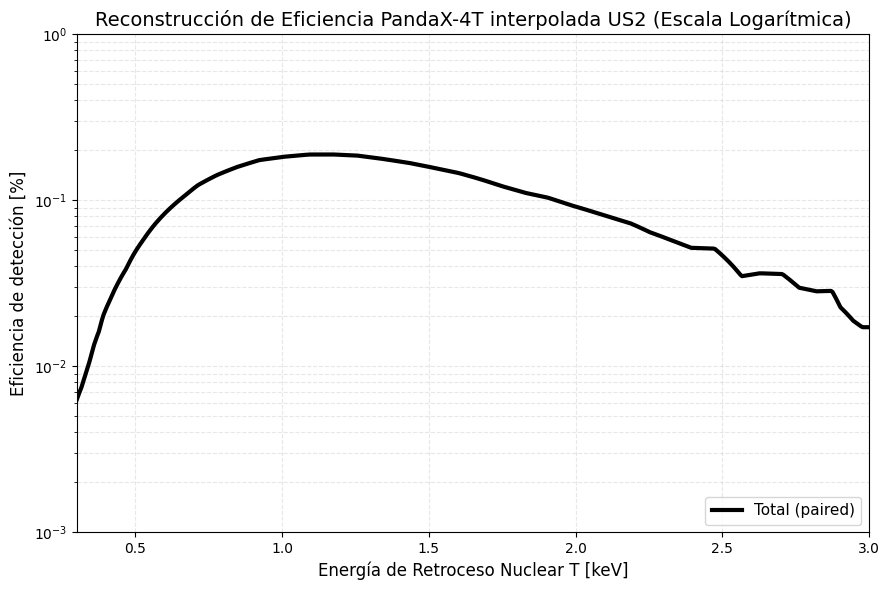

In [8]:
#Grafica eficiencia PandaX interpolada

# Vectorizamos para plotear
eficiencia_vec_P = np.vectorize(eficiencia_PandaX_interpolada)

# Eje X de 0.3 a 3.0 keV (Igual que en el paper)
T_vals = np.linspace(0.3, 3.0, 500)
# ¡Ojo! No multiplicamos por 100 aquí para mantener la escala absoluta de 10^-3 a 10^0
eff_vals_P = eficiencia_vec_P(T_vals) 

# Reemplazamos los ceros por un número minúsculo para que el logaritmo no dé error
eff_vals_P = np.where(eff_vals_P == 0, 1e-10, eff_vals_P)

# ==========================================
# CREACIÓN DE LA GRÁFICA (ESTILO PAPER)
# ==========================================
plt.figure(figsize=(9, 6))

plt.plot(T_vals, eff_vals_P, color='black', linewidth=3, 
         label='Total (paired)')


# Configuramos el eje Y en escala logarítmica para igualar tu imagen
plt.yscale('log')
plt.ylim(1e-3, 1e0) # De 10^-3 a 10^0
plt.xlim(0.3, 3.0)

# Estética
plt.title('Reconstrucción de Eficiencia PandaX-4T interpolada US2 (Escala Logarítmica)', fontsize=14)
plt.xlabel('Energía de Retroceso Nuclear T [keV]', fontsize=12)
plt.ylabel('Eficiencia de detección [%]', fontsize=12)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

plt.show()

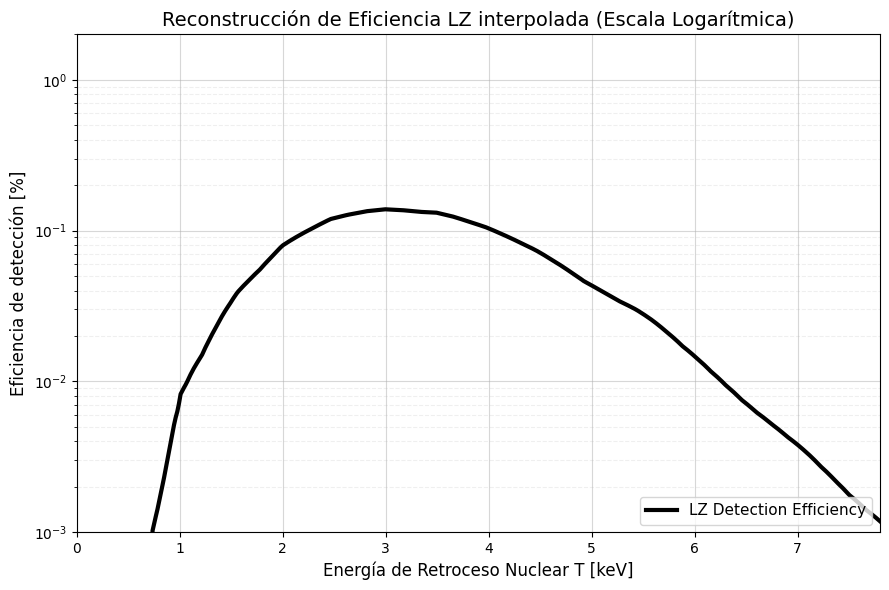

ATENCIÓN: La eficiencia máxima calculada es: 0.1384


In [9]:
# ==========================================
# GRÁFICA EFICIENCIA LZ (ESCALA LOGARÍTMICA)
# ==========================================

# Vectorizamos para plotear
eficiencia_vec_LZ = np.vectorize(eficiencia_LZ_interpolada)

T_vals = np.linspace(0.0, 8.0, 500)
eff_vals_LZ = eficiencia_vec_LZ(T_vals) 

# Protegemos el logaritmo sustituyendo los 0.0 por un número minúsculo
eff_vals_LZ = np.where(eff_vals_LZ <= 0, 1e-10, eff_vals_LZ)

plt.figure(figsize=(9, 6))

plt.plot(T_vals, eff_vals_LZ, color='black', linewidth=3, 
         label='LZ Detection Efficiency')



# EJE Y LOGARÍTMICO
plt.yscale('log')
plt.ylim(1e-3, 2.0) # Desde 10^-4 hasta 2.0 para ver si llega al 1.0
plt.xlim(0, 7.8)

# Estética
plt.title('Reconstrucción de Eficiencia LZ interpolada (Escala Logarítmica)', fontsize=14)
plt.xlabel('Energía de Retroceso Nuclear T [keV]', fontsize=12)
plt.ylabel('Eficiencia de detección [%]', fontsize=12)

plt.grid(True, which="major", ls="-", alpha=0.5)
plt.grid(True, which="minor", ls="--", alpha=0.2)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

plt.show()

# --- CHIVATO DE DEPURACIÓN ---
print(f"ATENCIÓN: La eficiencia máxima calculada es: {eff_vals_LZ.max():.4f}")

In [10]:
# --- 1. Definimos la Región de Interés (ROI) ---
# ¡ATENCIÓN! Cambia estos valores por los que digan los papers exactos.
umbral_inferior_X = 0.5  # keV (T_min típico)
umbral_superior_X = 10  # keV (T_max)

umbral_inferior_P = 1.1  # keV (T_min típico)
umbral_superior_P = 10  # keV (T_max)

umbral_inferior_P_US2 = 0.33  # keV (T_min típico)
umbral_superior_P_US2 = 10  # keV (T_max)

umbral_inferior_LZ = 1  # keV (T_min típico)
umbral_superior_LZ = 6  # keV (T_max)

tasa_diaria_esperada_X = tasa_total_ton_dia_XENONnT(umbral_inferior_X, umbral_superior_X)
tasa_diaria_esperada_X_interpol = tasa_total_ton_dia_XENONnT_interpol(umbral_inferior_X, umbral_superior_X)
tasa_diaria_esperada_P = tasa_total_ton_dia_PandaX(umbral_inferior_P, umbral_superior_P)
tasa_diaria_esperada_P_US2 = tasa_total_ton_dia_PandaX_interpol(umbral_inferior_P_US2, umbral_superior_P_US2)
tasa_diaria_esperada_LZ = tasa_total_ton_dia_LZ_interpol(umbral_inferior_LZ, umbral_superior_LZ)
print("-" * 50)
print(f"Tasa diaria teórica (ROI: {umbral_inferior_X}-{umbral_superior_X} keV):")
print(f"-> {tasa_diaria_esperada_X:.4f} eventos / tonelada / día")
print(f"Tasa diaria teórica (ROI: {umbral_inferior_P}-{umbral_superior_P} keV):")
print(f"-> {tasa_diaria_esperada_P:.4f} eventos / tonelada / día")
print(f"Tasa diaria teórica (ROI: {umbral_inferior_LZ}-{umbral_superior_LZ} keV):")
print(f"-> {tasa_diaria_esperada_LZ:.4f} eventos / tonelada / día")
print("-" * 50)

# --- 2. Comparación con los Experimentos ---
# La exposición se mide en [toneladas x día]. 
# Ej: Si XENONnT corrió con 4 toneladas durante 200 días -> Exposición = 800 ton-días.
# (Sustituye estos números por las exposiciones reales publicadas en sus artículos)

exposicion_XENONnT = 1281.15    # Ejemplo: 1 tonelada-año
exposicion_PandaX = 438   # Ejemplo: ~0.5 toneladas-año
exposicion_PandaX_US2 = 379.86
exposicion_LZ = 2082


eventos_XENONnT = tasa_diaria_esperada_X * exposicion_XENONnT
eventos_XENONnT_interpol = tasa_diaria_esperada_X_interpol * exposicion_XENONnT
eventos_PandaX = tasa_diaria_esperada_P * exposicion_PandaX
eventos_PandaX_US2 = tasa_diaria_esperada_P_US2 * exposicion_PandaX_US2
eventos_LZ = tasa_diaria_esperada_LZ * exposicion_LZ

print("NÚMERO TOTAL DE EVENTOS ESPERADOS (CEvNS Boro-8):")
print(f"XENONnT   (Expo: {exposicion_XENONnT} ton-día) -> {eventos_XENONnT:.2f} eventos")
print(f"XENONnT interpolado  (Expo: {exposicion_XENONnT} ton-día) -> {eventos_XENONnT_interpol:.2f} eventos")
print(f"PandaX-4T (Expo: {exposicion_PandaX} ton-día) -> {eventos_PandaX:.2f} eventos paired")
print(f"PandaX-4T interpolado (Expo: {exposicion_PandaX_US2} ton-día) -> {eventos_PandaX_US2:.2f} eventos US2")
print(f"LZ (Expo: {exposicion_LZ} ton-día) -> {eventos_LZ:.2f} eventos")
print("-" * 50)


--------------------------------------------------
Tasa diaria teórica (ROI: 0.5-10 keV):
-> 0.0085 eventos / tonelada / día
Tasa diaria teórica (ROI: 1.1-10 keV):
-> 0.0052 eventos / tonelada / día
Tasa diaria teórica (ROI: 1-6 keV):
-> 0.0074 eventos / tonelada / día
--------------------------------------------------
NÚMERO TOTAL DE EVENTOS ESPERADOS (CEvNS Boro-8):
XENONnT   (Expo: 1281.15 ton-día) -> 10.85 eventos
XENONnT interpolado  (Expo: 1281.15 ton-día) -> 10.89 eventos
PandaX-4T (Expo: 438 ton-día) -> 2.26 eventos paired
PandaX-4T interpolado (Expo: 379.86 ton-día) -> 46.17 eventos US2
LZ (Expo: 2082 ton-día) -> 15.36 eventos
--------------------------------------------------


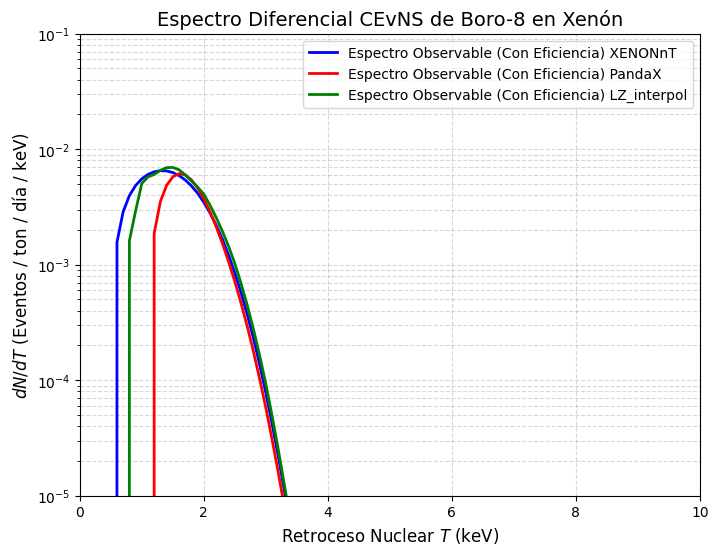

In [11]:
# ==========================================
# 4. EJECUCIÓN Y GRÁFICA
# ==========================================

# Generamos 100 puntos de energía entre 0.1 y 10 keV
recoils_keV = np.linspace(0.1, 10.0, 100)
tasas_atomo_XENONnT = [calcular_dNdT_XENONnT(T) for T in recoils_keV]
tasas_atomo_PandaX = [calcular_dNdT_PandaX(T) for T in recoils_keV]
tasas_atomo_LZ_interpol = [calcular_dNdT_LZ_interpol(T) for T in recoils_keV]

# Factor para pasar de "por átomo" a "por tonelada"
atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
tasas_tonelada_XENONnT = np.array(tasas_atomo_XENONnT) * atomos_por_tonelada
tasas_tonelada_PandaX = np.array(tasas_atomo_PandaX) * atomos_por_tonelada
tasas_tonelada_LZ_interpol = np.array(tasas_atomo_LZ_interpol) * atomos_por_tonelada

# Cálculo de eventos absolutos para un experimento concreto (Ej: LZ)
live_time_dias = 1000.0
masa_activa_toneladas = 7.0
eventos_absolutos_XENONnT = tasas_tonelada_XENONnT *exposicion_XENONnT
eventos_absolutos_PandaX = tasas_tonelada_PandaX *exposicion_PandaX
eventos_absolutos_LZ_interpol = tasas_tonelada_LZ_interpol *exposicion_LZ


# --- DIBUJO DE LA GRÁFICA ---
plt.figure(figsize=(8,6))

# Graficamos la tasa diaria diferencial (el estándar de la industria)
plt.plot(recoils_keV, tasas_tonelada_XENONnT, 'b-', lw=2, label='Espectro Observable (Con Eficiencia) XENONnT')
plt.plot(recoils_keV, tasas_tonelada_PandaX, 'r-', lw=2, label='Espectro Observable (Con Eficiencia) PandaX')
plt.plot(recoils_keV, tasas_tonelada_LZ_interpol, 'g-', lw=2, label='Espectro Observable (Con Eficiencia) LZ_interpol')

plt.yscale('log')
plt.xlabel('Retroceso Nuclear $T$ (keV)', fontsize=12)
plt.ylabel('$dN/dT$ (Eventos / ton / día / keV)', fontsize=12)

# Actualizamos el título para reflejar que incluye el umbral del detector
plt.title('Espectro Diferencial CEvNS de Boro-8 en Xenón', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Establecemos los límites del eje X y el Y para que se vea perfectamente el "pico"
plt.xlim(0, 10)
plt.ylim(1e-5, 1e-1) # Ajusta este 1e-1 si tu pico se sale por arriba

plt.legend()
plt.show()

Total XENONnT: 10.85 eventos
Total PandaX:  46.35 eventos
Total LZ:      15.35 eventos


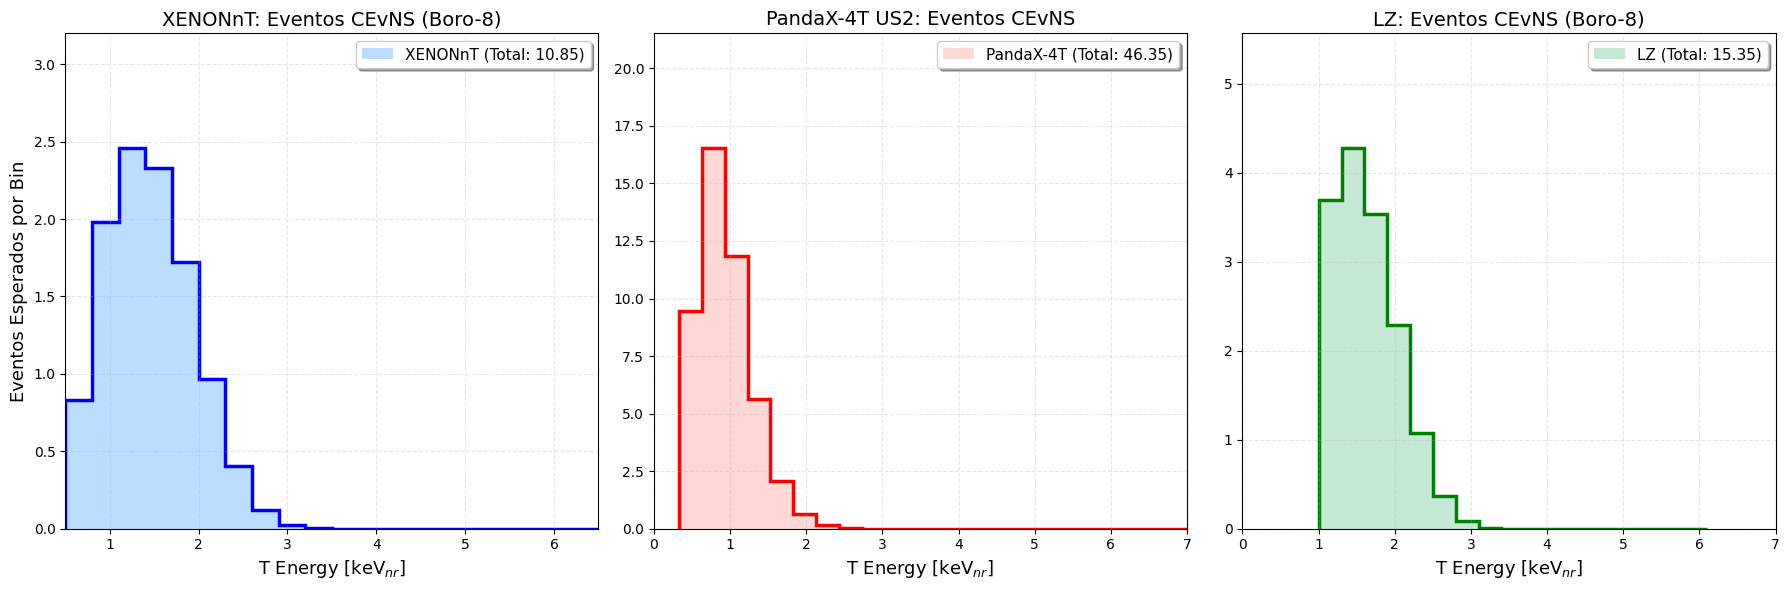

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ==========================================
# DEFINICIÓN DE LOS BINES
# ==========================================
ancho_bin = 0.3

# Asegúrate de que los umbrales superiores incluyan el último borde. 
# Si tu rango es de 0 a 6.5, np.arange(0, 7.0, 0.5) te dará los 14 bordes necesarios.
# Sumar ancho_bin garantiza que el último borde llegue (o cubra) el límite superior
bin_edges_XENONnT = np.arange(umbral_inferior_X, umbral_superior_X + ancho_bin, ancho_bin)
bin_edges_PandaX = np.arange(umbral_inferior_P_US2, umbral_superior_P_US2 + ancho_bin, ancho_bin)
bin_edges_LZ = np.arange(umbral_inferior_LZ, umbral_superior_LZ + ancho_bin, ancho_bin)

eventos_bines_XENON = []
eventos_bines_PandaX = []
eventos_bines_LZ = []

# ==========================================
# CÁLCULO DE EVENTOS POR BIN (DOBLE INTEGRAL)
# ==========================================
# BUCLE 1: EXCLUSIVO PARA XENONnT
for i in range(len(bin_edges_XENONnT) - 1):
    T_inf = bin_edges_XENONnT[i]
    T_sup = bin_edges_XENONnT[i+1]
    
    # Integramos la tasa diferencial dentro de este bin para XENONnT
    tasa_X_atomo, _ = quad(calcular_dNdT_XENONnT, T_inf, T_sup)
    tasa_X_tonelada = tasa_X_atomo * atomos_por_tonelada
    eventos_X = tasa_X_tonelada * exposicion_XENONnT
    eventos_bines_XENON.append(eventos_X)

# BUCLE 2: EXCLUSIVO PARA PandaX-4T
for i in range(len(bin_edges_PandaX) - 1):
    T_inf = bin_edges_PandaX[i]
    T_sup = bin_edges_PandaX[i+1]
    
    # EL TRUCO: Le decimos a la integral que use el borde del bin, 
    # a menos que el borde se pase del umbral superior. En ese caso, corta en el umbral.
    limite_superior_integral = min(T_sup, umbral_superior_P)
    
    # Solo integramos si el inicio del bin no está ya por encima del límite
    if T_inf < umbral_superior_P_US2:
        tasa_P_atomo, _ = quad(calcular_dNdT_PandaX_interpol, T_inf, limite_superior_integral)
        tasa_P_tonelada = tasa_P_atomo * atomos_por_tonelada
        eventos_P = tasa_P_tonelada * exposicion_PandaX_US2
        eventos_bines_PandaX.append(eventos_P)
    else:
        # Si el bin se sale completamente de rango, los eventos son 0
        eventos_bines_PandaX.append(0.0)


# BUCLE 3: LZ
for i in range(len(bin_edges_LZ) - 1):
    T_inf = bin_edges_LZ[i]
    T_sup = bin_edges_LZ[i+1]
    
    limite_superior_integral = min(T_sup, umbral_superior_LZ)
    
    if T_inf < umbral_superior_LZ:
        tasa_LZ_atomo, _ = quad(calcular_dNdT_LZ_interpol, T_inf, limite_superior_integral)
        tasa_LZ_tonelada = tasa_LZ_atomo * atomos_por_tonelada
        eventos_LZ = tasa_LZ_tonelada * exposicion_LZ
        eventos_bines_LZ.append(eventos_LZ)
    else:
        eventos_bines_LZ.append(0.0)


# Imprimimos en consola para verificar
print(f"Total XENONnT: {sum(eventos_bines_XENON):.2f} eventos")
print(f"Total PandaX:  {sum(eventos_bines_PandaX):.2f} eventos")
print(f"Total LZ:      {sum(eventos_bines_LZ):.2f} eventos")

# ==========================================
# GRÁFICA DE DOS PANELES
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# ------------------------------------------
# PANEL IZQUIERDO: XENONnT
# ------------------------------------------
# Ahora usamos bin_edges_XENONnT directamente
ax1.stairs(eventos_bines_XENON, bin_edges_XENONnT, color='dodgerblue', fill=True, alpha=0.3, 
           label=f'XENONnT (Total: {sum(eventos_bines_XENON):.2f})')
ax1.stairs(eventos_bines_XENON, bin_edges_XENONnT, color='blue', linewidth=2.5)

ax1.set_title('XENONnT: Eventos CEvNS (Boro-8)', fontsize=14)
ax1.set_xlabel('T Energy [keV$_{nr}$]', fontsize=13)
ax1.set_ylabel('Eventos Esperados por Bin', fontsize=13)

ax1.set_xlim(0.5, 6.5)
ax1.set_ylim(0, max(eventos_bines_XENON) * 1.3)
ax1.grid(alpha=0.3, linestyle='--')
ax1.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

# ------------------------------------------
# PANEL CENTRAL: PandaX-4T
# ------------------------------------------
ax2.stairs(eventos_bines_PandaX, bin_edges_PandaX, color='salmon', fill=True, alpha=0.3, 
           label=f'PandaX-4T (Total: {sum(eventos_bines_PandaX):.2f})')
ax2.stairs(eventos_bines_PandaX, bin_edges_PandaX, color='red', linewidth=2.5)

ax2.set_title('PandaX-4T US2: Eventos CEvNS', fontsize=14)
ax2.set_xlabel('T Energy [keV$_{nr}$]', fontsize=13)
ax2.set_xlim(0.0, 7.0)
ax2.set_ylim(0, max(eventos_bines_PandaX) * 1.3 if max(eventos_bines_PandaX) > 0 else 1)
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)


# ------------------------------------------
# PANEL DERECHO: LZ
# ------------------------------------------
ax3.stairs(eventos_bines_LZ, bin_edges_LZ, color='mediumseagreen', fill=True, alpha=0.3, 
           label=f'LZ (Total: {sum(eventos_bines_LZ):.2f})')
ax3.stairs(eventos_bines_LZ, bin_edges_LZ, color='green', linewidth=2.5)

ax3.set_title('LZ: Eventos CEvNS (Boro-8)', fontsize=14)
ax3.set_xlabel('T Energy [keV$_{nr}$]', fontsize=13)
ax3.set_xlim(0.0, 7.0)
ax3.set_ylim(0, max(eventos_bines_LZ) * 1.3 if max(eventos_bines_LZ) > 0 else 1)
ax3.grid(alpha=0.3, linestyle='--')
ax3.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

# ------------------------------------------
# Ajuste final y mostrar
# ------------------------------------------
plt.tight_layout()
plt.show()

Calculando constante (K) para LZ...

   RESULTADO EXPERIMENTAL PURO: LZ
K : 2.9261e-06 [eventos / (cm^-2 s^-1)]
Eventos Observados            : 12.3 ± 6.2
--------------------------------------------------
FLUJO INFERIDO DE BORO-8      : (4.20 ± 2.12) x 10^6 cm^-2 s^-1

Calculando constante (K) para XENONnT...

   RESULTADO EXPERIMENTAL PURO: XENONNT
K : 2.0740e-06 [eventos / (cm^-2 s^-1)]
Eventos Observados            : 10.7 ± 4.0
--------------------------------------------------
FLUJO INFERIDO DE BORO-8      : (5.16 ± 1.90) x 10^6 cm^-2 s^-1

Calculando constante (K) para PandaX...

   RESULTADO EXPERIMENTAL PURO: PANDAX
K : 8.7944e-06 [eventos / (cm^-2 s^-1)]
Eventos Observados            : 43.0 ± 28.0
--------------------------------------------------
FLUJO INFERIDO DE BORO-8      : (4.89 ± 3.18) x 10^6 cm^-2 s^-1



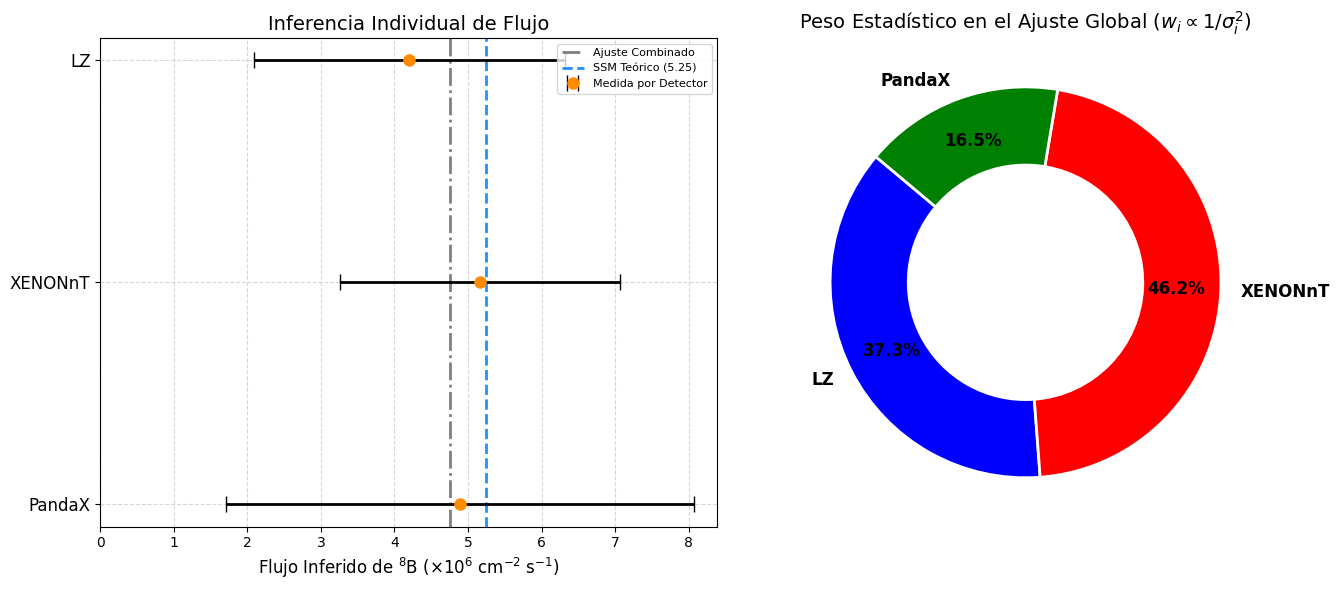


Flujo Global Combinado (Mejor Ajuste) : (4.76 ± 1.29) x 10^6 cm^-2 s^-1
-----------------------------------------------------------------
Test de Compatibilidad con el Modelo Solar Estándar (SSM):
 -> Hipótesis nula (Flujo SSM)        : 5.25 x 10^6 cm^-2 s^-1
 -> Chi-cuadrado total (\chi^2)       : 0.26
 -> Grados de libertad (dof)          : 3
 -> Chi-cuadrado reducido (\chi^2/dof): 0.09



In [13]:
# ==========================================
# 4. INFERENCIA EXPERIMENTAL CIEGA (PROBLEMA INVERSO)
# ==========================================

def flujo_B8_PDF(E_nu):
    """ 
    Densidad de Probabilidad (PDF) del Boro-8. 
    Solo da la forma estadística, aislando por completo el flujo teórico (SSM).
    """
    if E_nu < 0.1 or E_nu > 16.5:
        return 0.0
    return float(flujo_B8_interpolado(E_nu))

# --- 4.1. Integrandos de Sensibilidad Intrínseca ---
def integrando_K_LZ(E_nu, T_keV):
    return flujo_B8_PDF(E_nu) * dsigma_dT(E_nu, T_keV) * eficiencia_LZ_interpolada(T_keV)

def integrando_K_XENONnT(E_nu, T_keV):
    return flujo_B8_PDF(E_nu) * dsigma_dT(E_nu, T_keV) * eficiencia_XENONnT_interpolada(T_keV)

def integrando_K_PandaX(E_nu, T_keV):
    return flujo_B8_PDF(E_nu) * dsigma_dT(E_nu, T_keV) * eficiencia_PandaX_interpolada(T_keV)

# --- 4.2. Tasas Diferenciales de Sensibilidad (dK/dT) ---
def calcular_dKdT_LZ(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.0 
    if E_min >= E_max: return 0.0
    integral, _ = quad(integrando_K_LZ, E_min, E_max, args=(T_keV,))
    return integral * 86400

def calcular_dKdT_XENONnT(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.0 
    if E_min >= E_max: return 0.0
    integral, _ = quad(integrando_K_XENONnT, E_min, E_max, args=(T_keV,))
    return integral * 86400

def calcular_dKdT_PandaX(T_keV):
    T_MeV = T_keV * 1e-3
    E_min = np.sqrt(M_Xe * T_MeV / 2.0)
    E_max = 16.0 
    if E_min >= E_max: return 0.0
    integral, _ = quad(integrando_K_PandaX, E_min, E_max, args=(T_keV,))
    return integral * 86400

# --- 4.3. Constante de Calibración Total K ---
def calcular_K_detector(detector, T_min, T_max, exposicion_ton_dia):
    """
    Calcula la sensibilidad de la máquina en [Eventos / (cm^-2 s^-1)]
    """
    if detector == 'LZ':
        res_atomo, _ = quad(calcular_dKdT_LZ, T_min, T_max, epsrel=1e-3)
    elif detector == 'XENONnT':
        res_atomo, _ = quad(calcular_dKdT_XENONnT, T_min, T_max, epsrel=1e-3)
    elif detector == 'PandaX':
        res_atomo, _ = quad(calcular_dKdT_PandaX, T_min, T_max, epsrel=1e-3)
    else:
        raise ValueError("Detector no soportado. Elige 'LZ', 'XENONnT' o 'PandaX'")
        
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    K_total = res_atomo * atomos_por_tonelada * exposicion_ton_dia
    return K_total

# --- 4.4. LA FUNCIÓN MAESTRA ---
def inferir_flujo_experimental(eventos_obs, error_obs, detector, T_min, T_max, exposicion):
    """
    Infiere el flujo real del Sol recibiendo únicamente los clics del detector y su error.
    """
    print(f"Calculando constante (K) para {detector}...")
    K_det = calcular_K_detector(detector, T_min, T_max, exposicion)
    
    flujo_inferido = eventos_obs / K_det
    error_flujo = error_obs / K_det

    

    
    print("\n" + "="*50)
    print(f"   RESULTADO EXPERIMENTAL PURO: {detector.upper()}")
    print("="*50)
    print(f"K : {K_det:.4e} [eventos / (cm^-2 s^-1)]")
    print(f"Eventos Observados            : {eventos_obs:.1f} ± {error_obs:.1f}")
    print("-" * 50)
    print(f"FLUJO INFERIDO DE BORO-8      : ({flujo_inferido/1e6:.2f} ± {error_flujo/1e6:.2f}) x 10^6 cm^-2 s^-1")
    print("="*50 + "\n")
    
    return flujo_inferido, error_flujo, K_det


# ==========================================
# 5. EJEMPLOS DE USO (¡Prueba con tus datos!)
# ==========================================

if __name__ == "__main__":
    # --- Ejemplo para LZ ---
    eventos_lz = 12.3
    error_lz = 6.2
    
    _,_,K_detLZ =inferir_flujo_experimental(
        eventos_obs=eventos_lz, 
        error_obs=error_lz, 
        detector='LZ', 
        T_min=umbral_inferior_LZ, 
        T_max=umbral_superior_LZ, 
        exposicion=exposicion_LZ
    )
    
    eventos_xe = 10.7 # Sustituye por el número del paper
    error_xe = 3.95
    _,_,K_detXENONnT=inferir_flujo_experimental(eventos_xe, error_xe, 'XENONnT', umbral_inferior_X, umbral_superior_X, exposicion_XENONnT)

    eventos_PandaX = 43 # Sustituye por el número del paper
    error_PandaX = 28
    _,_,K_detPandaX=inferir_flujo_experimental(eventos_PandaX, error_PandaX, 'PandaX', umbral_inferior_P_US2, umbral_superior_P_US2, exposicion_PandaX_US2)

eventos_observados=[eventos_lz, eventos_xe, eventos_PandaX]
eventos_esperados=[K_detLZ*5.25e6, K_detXENONnT*5.25e6, K_detPandaX*5.25e6]
error_experimental=[error_lz, error_xe, error_PandaX]

chi2_flujo,chi2_partes_flujo=chi_cuadrado_1variable(eventos_observados, eventos_esperados, error_experimental)


K_arrays = np.array([K_detLZ, K_detXENONnT, K_detPandaX])

# El flujo inferido es simplemente Observados / K (y dividimos por 1e6 para el eje)
flujos_inferidos = np.array(eventos_observados) / K_arrays / 1e6
errores_flujos = np.array(error_experimental) / K_arrays / 1e6

# Cálculo analítico del ajuste combinado (media ponderada por la varianza inversa)
pesos = 1.0 / (errores_flujos**2)
flujo_combinado = np.average(flujos_inferidos, weights=pesos)
error_combinado = np.sqrt(1.0 / np.sum(pesos))
pesos_relativos = (pesos / np.sum(pesos)) * 100

# --- CONFIGURACIÓN DE LA GRÁFICA ---
detectores = ['LZ', 'XENONnT', 'PandaX']
y_pos = np.arange(len(detectores))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# PANEL 1: OBSERVADOS VS ESPERADOS (Parte por parte)
# ==========================================
# Barras teóricas (El flujo perfecto del SSM)
# 1. Franja vertical del ajuste global combinado
ax1.axvline(flujo_combinado, color='gray', linestyle='-.', lw=2, zorder=1, label=f'Ajuste Combinado')

# 2. Línea vertical del Modelo Solar Estándar
ax1.axvline(5.25, color='dodgerblue', linestyle='--', lw=2, zorder=1, label='SSM Teórico (5.25)')

# 3. Los puntos de los detectores con sus barras horizontales
ax1.errorbar(flujos_inferidos, y_pos, xerr=errores_flujos, fmt='o', 
             color='darkorange', ecolor='black', elinewidth=2, capsize=6, 
             markersize=8, zorder=3, label='Medida por Detector')

# Detalles estéticos del Panel 1
ax1.set_yticks(y_pos)
ax1.set_yticklabels(detectores, fontsize=12)
ax1.invert_yaxis()  # Para que LZ quede arriba y PandaX abajo
ax1.set_xlabel(r'Flujo Inferido de $^{8}$B ($\times 10^6$ cm$^{-2}$ s$^{-1}$)', fontsize=12)
ax1.set_title('Inferencia Individual de Flujo', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', fontsize=8)

# Para que el eje X respire y se vea bien PandaX
ax1.set_xlim(left=0)


# ==========================================
# PANEL 2: GRÁFICO DE ANILLO (Pesos Estadísticos)
# ==========================================
# Colores profesionales para cada detector
colores = ['blue', 'red', 'green'] 

# Creamos el gráfico de sectores
wedges, texts, autotexts = ax2.pie(
    pesos_relativos, 
    labels=detectores, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colores,
    pctdistance=0.77,
    wedgeprops=dict(width=0.4, edgecolor='white', lw=2), # Esto lo convierte en anillo
    textprops=dict(fontsize=12, fontweight='bold')
)

# Estética de los textos dentro del anillo
for autotext in autotexts:
    autotext.set_color('black')

ax2.set_title('Peso Estadístico en el Ajuste Global ($w_i \propto 1/\sigma_i^2$)', fontsize=14)

plt.tight_layout()
plt.show()


dof = 3

print("\n" + "="*65)
print("="*65)
print(f"Flujo Global Combinado (Mejor Ajuste) : ({flujo_combinado:.2f} ± {error_combinado:.2f}) x 10^6 cm^-2 s^-1")
print("-" * 65)
print("Test de Compatibilidad con el Modelo Solar Estándar (SSM):")
print(f" -> Hipótesis nula (Flujo SSM)        : 5.25 x 10^6 cm^-2 s^-1")
print(f" -> Chi-cuadrado total (\chi^2)       : {chi2_flujo:.2f}")
print(f" -> Grados de libertad (dof)          : {dof}")
print(f" -> Chi-cuadrado reducido (\chi^2/dof): {chi2_flujo/dof:.2f}")
print("="*65 + "\n")


   MEDIDA DEL ÁNGULO DE WEINBERG: LZ
Constante K_EW del detector : 0.00 [Eventos / Q_W^2]
Eventos Observados          : 12.3 ± 6.2
------------------------------------------------------------
Valor téorico del sin²(θ_W) (SM): 0.24
sin^2(θ_W) Experimental : 0.20 ± 0.08


   MEDIDA DEL ÁNGULO DE WEINBERG: XENONNT
Constante K_EW del detector : 0.00 [Eventos / Q_W^2]
Eventos Observados          : 10.7 ± 4.0
------------------------------------------------------------
Valor téorico del sin²(θ_W) (SM): 0.24
sin^2(θ_W) Experimental : 0.24 ± 0.06


   MEDIDA DEL ÁNGULO DE WEINBERG: PANDAX
Constante K_EW del detector : 0.01 [Eventos / Q_W^2]
Eventos Observados          : 43.0 ± 28.0
------------------------------------------------------------
Valor téorico del sin²(θ_W) (SM): 0.24
sin^2(θ_W) Experimental : 0.23 ± 0.11



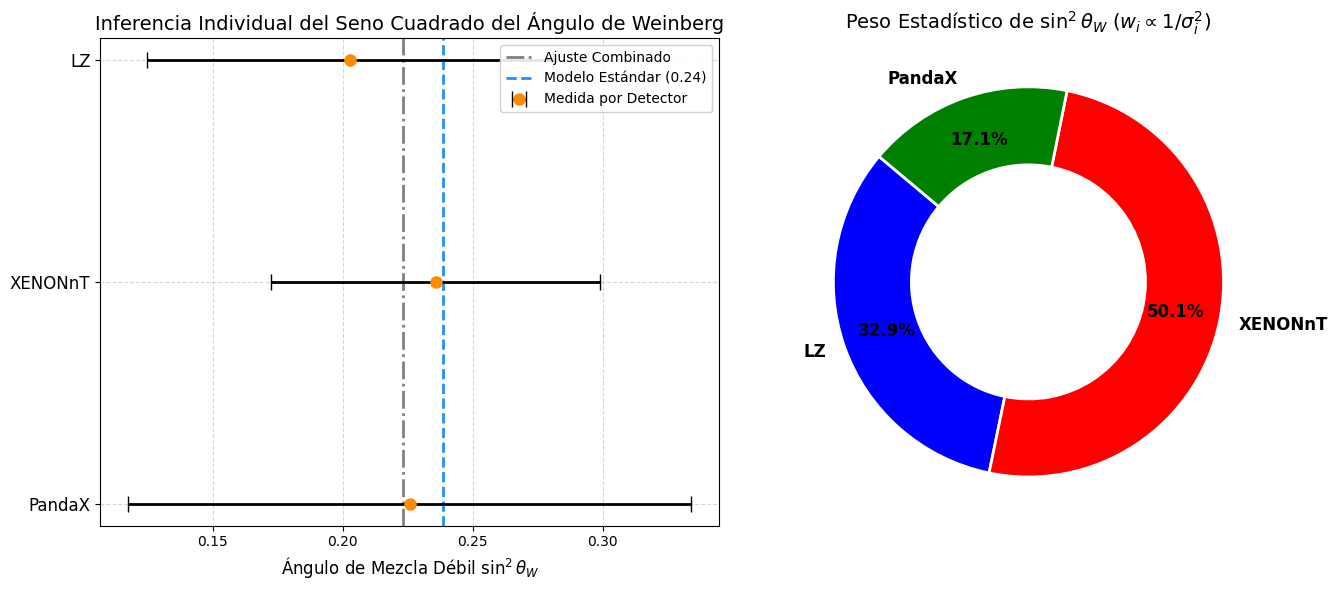


Mejor Ajuste Combinado : sin^2(	heta_W) = 0.22 ± 0.04
Predicción Teórica (SM): 0.24
Chi-cuadrado total     : 0.25 (dof = 3)
Chi-cuadrado reducido  : 0.08



In [18]:
# ==========================================
# 5. INFERENCIA DEL ÁNGULO DE MEZCLA DÉBIL 
# ==========================================

def dsigma_dT_cinematica(E_nu, T_keV):
        """
        Parte puramente cinemática de la sección eficaz diferencial CEvNS.
        ¡Q_w ha sido factorizado (extraído) de la ecuación!
        Salida en [cm^2 / (keV * Q_w^2)]
        """
        T_MeV = T_keV * 1e-3 
        E_min = np.sqrt(M_Xe * T_MeV / 2.0)
        
        if E_nu < E_min:
            return 0.0

        F_T = 1.0 # Factor de forma 
        
        # Término cinemático clásico
        termino_cinematico = 1.0 - (M_Xe * T_MeV) / (2.0 * E_nu**2)
        
        if termino_cinematico < 0:
            return 0.0

        # LA MAGIA: Quitamos el * (Q_w**2) de aquí. 
        # Solo dejamos las constantes universales y la masa.
        constante_acoplamiento = (G_F**2 * M_Xe) / (4.0 * np.pi)
        dSig_dT_MeV = constante_acoplamiento * termino_cinematico * (F_T**2) * hbar_c2
        
        return dSig_dT_MeV * 1e-3

def calcular_K_EW_puro(detector, T_min, T_max, exposicion):
    """
    Calcula K_EW integrando DIRECTAMENTE la cinemática sin Q_W.
    """
    flujo_total = 5.25e6
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    tiempo_segundos = exposicion * 86400.0
    
    # Seleccionamos la función de eficiencia según el detector
    def eficiencia(T):
        if detector == 'XENONnT': return eficiencia_XENONnT_interpolada(T)
        elif detector == 'LZ': return eficiencia_LZ_interpolada(T)
        elif detector == 'PandaX': return eficiencia_PandaX_interpolada(T)
        else: return 1.0
    
    # La doble integral usando tu nueva función purgada
    def integrando(T_keV, E_nu):
        return flujo_B8_interpolado(E_nu) * dsigma_dT_cinematica(E_nu, T_keV) * eficiencia(T_keV)
        
    integral_doble, _ = dblquad(integrando, 0.1, 16.5, lambda E: T_min, lambda E: T_max)
    
    # K_EW nace directamente de multiplicar las constantes del tanque por la integral purgada
    K_EW = flujo_total * atomos_por_tonelada * tiempo_segundos * integral_doble
    return K_EW

def inferir_angulo_debil(eventos_obs, error_obs, detector, T_min, T_max, exposicion):
    
    N_neu = 77.0 # Asumiendo Xenon natural
    Z_pro = 54.0
    
    # 1. Calculamos K_EW directamente de la cinemática
    K_EW = calcular_K_EW_puro(detector, T_min, T_max, exposicion)
    
    # 2. ECUACIÓN MAESTRA: N = Q_w^2 * K_EW  =>  Q_w = sqrt(N / K_EW)
    Q_W_cuadrado = eventos_obs / K_EW
    Q_W_exp = np.sqrt(Q_W_cuadrado)
    
    # 3. Despeje del ángulo
    sin2_th_exp = (Q_W_exp - N_neu + Z_pro) / (4.0 * Z_pro)
    
    # 4. Propagación de Errores Analítica
    error_Q_W = error_obs / (2.0 * np.sqrt(K_EW * eventos_obs))
    error_sin2_th = error_Q_W / (4.0 * Z_pro)

    
    print("\n" + "="*60)
    print(f"   MEDIDA DEL ÁNGULO DE WEINBERG: {detector.upper()}")
    print("="*60)
    print(f"Constante K_EW del detector : {K_EW:.2f} [Eventos / Q_W^2]")
    print(f"Eventos Observados          : {eventos_obs:.1f} ± {error_obs:.1f}")
    print("-" * 60)
    print(f"Valor téorico del sin²(θ_W) (SM): {sin2_theta_w:.2f}")
    print(f"sin^2(\u03B8_W) Experimental : {sin2_th_exp:.2f} ± {error_sin2_th:.2f}")
    print("="*60 + "\n")
    
    return sin2_th_exp, error_sin2_th, K_EW



import numpy as np
import matplotlib.pyplot as plt

if __name__ == "__main__":
    # ==========================================
    # 1. RECOLECCIÓN DE DATOS
    # ==========================================
    # Asumo que tienes definidas las variables eventos_lz, error_lz, etc.
    sin2_lz, err_lz, KEW_lz = inferir_angulo_debil(eventos_lz, error_lz, 'LZ', umbral_inferior_LZ, umbral_superior_LZ, exposicion_LZ)
    sin2_xe, err_xe, KEW_xe = inferir_angulo_debil(eventos_xe, error_xe, 'XENONnT', umbral_inferior_X, umbral_superior_X, exposicion_XENONnT)
    sin2_px, err_px, KEW_px = inferir_angulo_debil(eventos_PandaX, error_PandaX, 'PandaX', umbral_inferior_P_US2, umbral_superior_P_US2, exposicion_PandaX_US2)

    # Vectores para la estadística
    eventos_observados = [eventos_lz, eventos_xe, eventos_PandaX]
    error_experimental = [error_lz, error_xe, error_PandaX]
    
    sin2_inferidos = np.array([sin2_lz, sin2_xe, sin2_px])
    errores_sin2 = np.array([err_lz, err_xe, err_px])
    KEW_arrays = np.array([KEW_lz, KEW_xe, KEW_px])
    
    # ==========================================
    # 2. CÁLCULO ESTADÍSTICO COMBINADO
    # ==========================================
    # Media ponderada (Varianza Inversa)
    pesos_absolutos = 1.0 / (errores_sin2**2)
    sin2_combinado = np.average(sin2_inferidos, weights=pesos_absolutos)
    error_combinado = np.sqrt(1.0 / np.sum(pesos_absolutos))
    pesos_relativos = (pesos_absolutos / np.sum(pesos_absolutos)) * 100

    # Valor teórico del Modelo Estándar a bajas energías (Q^2 -> 0)
    sin2_SM = 0.2387
    N_neu, Z_pro = 77.0, 54.0

    # Test de bondad frente al Modelo Estándar (Chi^2)
    Q_W_SM = N_neu - Z_pro * (1.0 - 4.0 * sin2_SM)
    eventos_esperados_SM = KEW_arrays * (Q_W_SM**2)
    chi2_SM_total, chi2_por_detector = chi_cuadrado_1variable(eventos_observados, eventos_esperados_SM, error_experimental)
   
    # ==========================================
    # 3. GRÁFICAS (Forest Plot + Donut Chart)
    # ==========================================
    detectores = ['LZ', 'XENONnT', 'PandaX']
    y_pos = np.arange(len(detectores))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # --- PANEL 1: FOREST PLOT ---
    ax1.axvline(sin2_combinado, color='gray', linestyle='-.', lw=2,label=f'Ajuste Combinado')
    ax1.axvline(sin2_SM, color='dodgerblue', linestyle='--', lw=2, zorder=1, label=f'Modelo Estándar ({sin2_SM:.2f})')

    ax1.errorbar(sin2_inferidos, y_pos, xerr=errores_sin2, fmt='o', 
                 color='darkorange', ecolor='black', elinewidth=2, capsize=6, 
                 markersize=8, zorder=3, label='Medida por Detector')

    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(detectores, fontsize=12)
    ax1.invert_yaxis()
    ax1.set_xlabel(r'Ángulo de Mezcla Débil $\sin^2\theta_W$', fontsize=12)
    ax1.set_title('Inferencia Individual del Seno Cuadrado del Ángulo de Weinberg', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right', fontsize=10, framealpha=0.9)


    # --- PANEL 2: DONUT CHART DE PESOS ---
    wedges, texts, autotexts = ax2.pie(
        pesos_relativos, 
        labels=detectores, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colores,
        pctdistance=0.77, 
        wedgeprops=dict(width=0.4, edgecolor='white', lw=2), 
        textprops=dict(fontsize=12, fontweight='bold')
    )

    for autotext in autotexts:
        autotext.set_color('black')

    ax2.set_title(r'Peso Estadístico de $\sin^2 \theta_W$ ($w_i \propto 1/\sigma_i^2$)', fontsize=14)

    plt.tight_layout()
    plt.show()

    dof = 3
    print("\n" + "="*65)
    print("="*65)
    print(f"Mejor Ajuste Combinado : sin^2(\theta_W) = {sin2_combinado:.2f} ± {error_combinado:.2f}")
    print(f"Predicción Teórica (SM): {sin2_SM:.2f}")
    print(f"Chi-cuadrado total     : {chi2_SM_total:.2f} (dof = {dof})")
    print(f"Chi-cuadrado reducido  : {chi2_SM_total/dof:.2f}")
    print("="*65 + "\n")



   MEDIDA DE LA SECCIÓN EFICAZ: XENONNT
Constante K del detector  : 8.82 x 10^39 [Eventos / cm^2]
Eventos Observados        : 10.7 ± 4.0
------------------------------------------------------------
Sección Eficaz (Exp)      : (1.2 ± 0.4) x 10^-39 cm^2


   MEDIDA DE LA SECCIÓN EFICAZ: LZ
Constante K del detector  : 12.45 x 10^39 [Eventos / cm^2]
Eventos Observados        : 12.3 ± 6.2
------------------------------------------------------------
Sección Eficaz (Exp)      : (1.0 ± 0.5) x 10^-39 cm^2


   MEDIDA DE LA SECCIÓN EFICAZ: PANDAX
Constante K del detector  : 37.41 x 10^39 [Eventos / cm^2]
Eventos Observados        : 43.0 ± 28.0
------------------------------------------------------------
Sección Eficaz (Exp)      : (1.1 ± 0.7) x 10^-39 cm^2



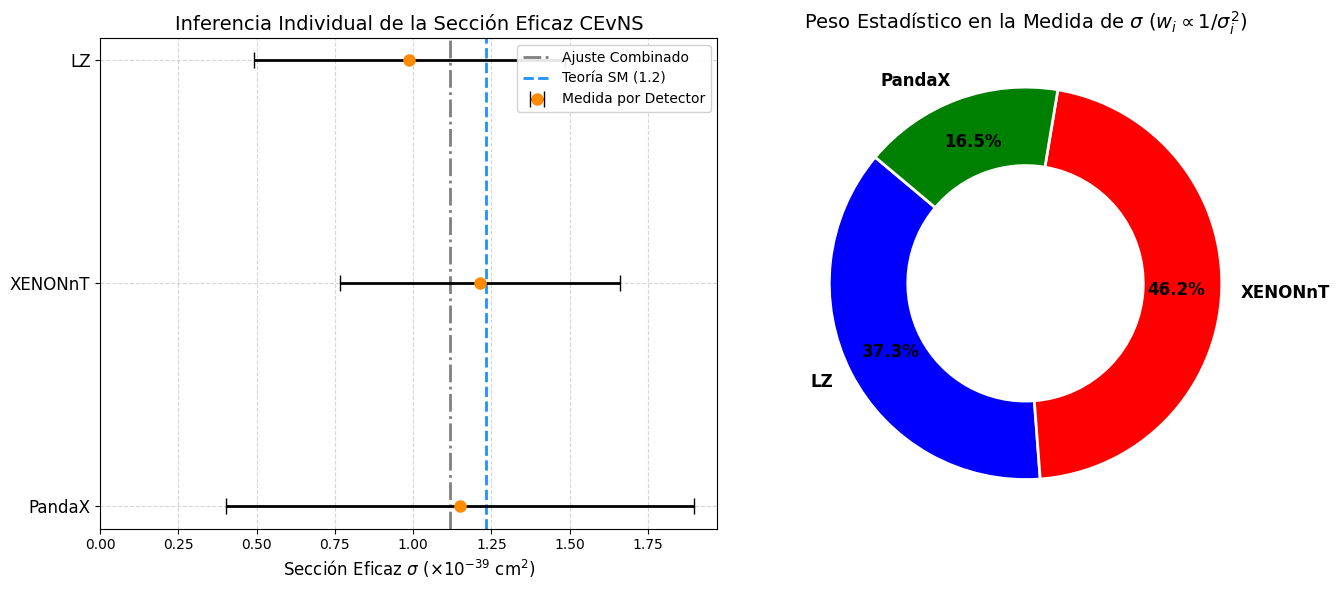


Mejor Ajuste Combinado : (1.12 ± 0.30) x 10^-39 cm^2
Predicción Teórica (SM): (1.2) x 10^-39 cm^2
Chi-cuadrado total     : 0.26 (dof = 3)
Chi-cuadrado reducido  : 0.09



In [19]:
# ==========================================
# 7. INFERENCIA DIRECTA DE LA SECCIÓN EFICAZ
# ==========================================

def calcular_seccion_eficaz_total_base():
    """ Calcula el tamaño 100% teórico para poder aislar la "forma" de la integral """
    def integrando(E_nu):
        if E_nu < 0.1 or E_nu > 16.5: return 0.0
        T_max_MeV = 2.0 * (E_nu**2) / M_Xe
        integral_T, _ = quad(lambda T: dsigma_dT(E_nu, T), 0.0, T_max_MeV * 1e3)
        return float(flujo_B8_interpolado(E_nu)) * integral_T
    res, _ = quad(integrando, 0.1, 16.5)
    return res

def calcular_K_sigma(detector, T_min, T_max, exposicion):
    """
    Construye tu constante geométrica aislando explícitamente el flujo y la exposición.
    """
    # 1. EL FLUJO ENTERO
    flujo_total = 5.25e6
    
    # 2. LAS CONSTANTES DE EXPOSICIÓN
    atomos_por_tonelada = (1000.0 / 0.131) * 6.022e23
    tiempo_segundos = exposicion * 86400.0
    
    # 3. LA ACEPTACIÓN (La integral dejando a sigma fuera)
    # Obtenemos los eventos de tu Celda 1 (que ya incluían flujo y átomos)
    if detector == 'XENONnT':
        eventos = tasa_total_ton_dia_XENONnT_interpol(T_min, T_max) * exposicion
    elif detector == 'LZ':
        eventos = tasa_total_ton_dia_LZ_interpol(T_min, T_max) * exposicion
    elif detector == 'PandaX':
        eventos = tasa_total_ton_dia_PandaX_interpol(T_min, T_max) * exposicion
        
    # Le "quitamos" el flujo y los átomos dividiendo para quedarnos con la integral pura de eficiencia
    integral_pura_eficiencia = eventos / (flujo_total * atomos_por_tonelada * tiempo_segundos)
    
    # Normalizamos con la sección teórica para "sacar" sigma de la integral
    sigma_base = calcular_seccion_eficaz_total_base()
    aceptacion_espectro = integral_pura_eficiencia / sigma_base
    
    # 4. LA CONSTANTE FINAL K (Flujo * Atomos * Tiempo * Aceptacion)
    K_sigma = flujo_total * atomos_por_tonelada * tiempo_segundos * aceptacion_espectro
    
    # Fíjate que algebraicamente, K_sigma es literalmente (eventos / sigma_base).
    # ¡Todo lo demás se cancela! Pero desglosarlo así demuestra la física que hay detrás.
    return K_sigma

def inferir_seccion_eficaz_directa(eventos_obs, error_obs, detector, T_min, T_max, exposicion):
    
    # Extraemos tu constante explícita K
    K_sigma = calcular_K_sigma(detector, T_min, T_max, exposicion)
    
    # INFERENCIA DIRECTA 
    sigma_exp = eventos_obs / K_sigma
    error_sigma = error_obs / K_sigma
    
    escala = 1e-39
    
    print("\n" + "="*60)
    print(f"   MEDIDA DE LA SECCIÓN EFICAZ: {detector.upper()}")
    print("="*60)
    print(f"Constante K del detector  : {K_sigma*escala:.2f} x 10^39 [Eventos / cm^2]")
    print(f"Eventos Observados        : {eventos_obs:.1f} ± {error_obs:.1f}")
    print("-" * 60)
    print(f"Sección Eficaz (Exp)      : ({sigma_exp/escala:.1f} ± {error_sigma/escala:.1f}) x 10^-39 cm^2")
    print("="*60 + "\n")
    
    return sigma_exp, error_sigma, K_sigma

# ==========================================
# 8. EJECUCIÓN DEL ANÁLISIS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

if __name__ == "__main__":
    
    # ==========================================
    # 1. RECOLECCIÓN DE DATOS
    # ==========================================
    sig_xe, err_sig_xe, K_xe = inferir_seccion_eficaz_directa(eventos_xe, error_xe, 'XENONnT', umbral_inferior_X, umbral_superior_X, exposicion_XENONnT)
    sig_lz, err_sig_lz, K_lz = inferir_seccion_eficaz_directa(eventos_lz, error_lz, 'LZ', umbral_inferior_LZ, umbral_superior_LZ, exposicion_LZ)
    sig_px, err_sig_px, K_px = inferir_seccion_eficaz_directa(eventos_PandaX, error_PandaX, 'PandaX', umbral_inferior_P_US2, umbral_superior_P_US2, exposicion_PandaX_US2)

    # Agrupamos en arrays (usamos el mismo orden para todos: LZ, XENONnT, PandaX)
    eventos_observados = np.array([eventos_lz, eventos_xe, eventos_PandaX])
    error_experimental = np.array([error_lz, error_xe, error_PandaX])
    
    sigma_inferidas = np.array([sig_lz, sig_xe, sig_px])
    errores_sigma = np.array([err_sig_lz, err_sig_xe, err_sig_px])
    K_arrays = np.array([K_lz, K_xe, K_px])

    # ==========================================
    # 2. CÁLCULO ESTADÍSTICO COMBINADO
    # ==========================================

    escala = 1e-39
    # Media ponderada (Varianza Inversa)
    pesos_absolutos = 1.0 / (errores_sigma**2)
    sigma_combinada = np.average(sigma_inferidas, weights=pesos_absolutos)
    error_combinado = np.sqrt(1.0 / np.sum(pesos_absolutos))
    pesos_relativos = (pesos_absolutos / np.sum(pesos_absolutos)) * 100

    # Valor Teórico Base (SSM)
    sigma_SM = calcular_seccion_eficaz_total_base()

    # Test de bondad frente al Modelo Estándar (Chi^2)
    # Eventos que esperaría ver cada detector si la sección eficaz fuera exactamente la teórica
    eventos_esperados_SM = K_arrays * sigma_SM 
    chi2_SM_total, chi2_por_detector = chi_cuadrado_1variable(eventos_observados, eventos_esperados_SM, error_experimental)

    # ==========================================
    # 3. TEXTO DE RESUMEN PARA LA MEMORIA
    # ==========================================
  

    # ==========================================
    # 4. GRÁFICAS (Forest Plot + Donut Chart)
    # ==========================================
    # Aplicamos la escala 1e-39 a todo para que el eje X del gráfico sea legible (ej: "3.5", "4.0"...)
    s_inf_esc = sigma_inferidas / escala
    err_s_esc = errores_sigma / escala
    s_comb_esc = sigma_combinada / escala
    err_comb_esc = error_combinado / escala
    s_SM_esc = sigma_SM / escala

    detectores = ['LZ', 'XENONnT', 'PandaX']
    y_pos = np.arange(len(detectores))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # --- PANEL 1: FOREST PLOT ---
    ax1.axvline(s_comb_esc, color='gray', linestyle='-.', lw=2,label=f'Ajuste Combinado')
    ax1.axvline(s_SM_esc, color='dodgerblue', linestyle='--', lw=2, zorder=1, label=f'Teoría SM ({s_SM_esc:.1f})')

    ax1.errorbar(s_inf_esc, y_pos, xerr=err_s_esc, fmt='o', 
                 color='darkorange', ecolor='black', elinewidth=2, capsize=6, 
                 markersize=8, zorder=3, label='Medida por Detector')

    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(detectores, fontsize=12)
    ax1.invert_yaxis()
    ax1.set_xlabel(r'Sección Eficaz $\sigma$ ($\times 10^{-39}$ cm$^2$)', fontsize=12)
    ax1.set_title('Inferencia Individual de la Sección Eficaz CEvNS', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right', fontsize=10, framealpha=0.9)
    ax1.set_xlim(left=0)


    # --- PANEL 2: DONUT CHART DE PESOS ---
    wedges, texts, autotexts = ax2.pie(
        pesos_relativos, 
        labels=detectores, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colores,
        pctdistance=0.77, 
        wedgeprops=dict(width=0.4, edgecolor='white', lw=2), 
        textprops=dict(fontsize=12, fontweight='bold')
    )

    for autotext in autotexts:
        autotext.set_color('black')

    ax2.set_title('Peso Estadístico en la Medida de $\sigma$ ($w_i \propto 1/\sigma_i^2$)', fontsize=14)


    dof = 3
    


    plt.tight_layout()
    plt.show()

    print("\n" + "="*65)
    print(f"Mejor Ajuste Combinado : ({sigma_combinada/escala:.2f} ± {error_combinado/escala:.2f}) x 10^-39 cm^2")
    print(f"Predicción Teórica (SM): ({1.2}) x 10^-39 cm^2")
    print(f"Chi-cuadrado total     : {chi2_SM_total:.2f} (dof = {dof})")
    print(f"Chi-cuadrado reducido  : {chi2_SM_total/dof:.2f}")
    print("="*65 + "\n")